# FDCH1 — Sampling, Data Selection & Fraud Classification

Dataset: **ULB credit-card fraud** (`data/creditcard.csv`) — 284,807 real European card transactions over two days in September 2013, of which 492 are fraudulent (0.173%).

`V1`–`V28` are PCA components published in place of the original fields for confidentiality. Only `Time`, `Amount` and `Class` are directly interpretable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("data/creditcard.csv")
print("shape:", df.shape)
df.head()

shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(list(df.columns))
df.dtypes.value_counts()

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


float64    30
int64       1
Name: count, dtype: int64

### Deriving a grouping column

This dataset has **no categorical column** — `V1`–`V28` are continuous PCA outputs. Stratified and cluster sampling both need groups, so we derive them from `Time`, which is seconds elapsed since the first transaction (0 to 172,792 = exactly 48 hours).

In [4]:
df["hour"] = ((df["Time"] // 3600) % 24).astype(int)   # hour of day, 24 levels
df["day"]  = (df["Time"] // 86400).astype(int)          # day 0 or 1

print("hour levels:", df["hour"].nunique(), "| day levels:", df["day"].nunique())
print("Time spans %.1f hours" % (df["Time"].max() / 3600))
print("\noverall fraud rate: %.5f" % df["Class"].mean())
df[["Time", "hour", "day", "Amount", "Class"]].head()

hour levels: 24 | day levels: 2
Time spans 48.0 hours

overall fraud rate: 0.00173


,Time,hour,day,Amount,Class
0,0.0,0,0,149.62,0
1,0.0,0,0,2.69,0
2,1.0,0,0,378.66,0
3,1.0,0,0,123.50,0
4,2.0,0,0,69.99,0


# Partition

In [5]:
split_fraction = 0.70
partition = df.sample(frac=split_fraction, random_state=42)
print("partition rows:", len(partition), "of", len(df))
print("fraud rate — full: %.5f | partition: %.5f" % (df["Class"].mean(), partition["Class"].mean()))

partition rows: 199365 of 284807
fraud rate — full: 0.00173 | partition: 0.00168


# Random

In [6]:
sample_random = df.sample(n=100, random_state=42)
print("rows:", len(sample_random), "| frauds captured:", int(sample_random["Class"].sum()))
sample_random.head()

rows: 100 | frauds captured: 1


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour,day
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,-14.110184,5.299236,-10.834006,1.671120,-9.373859,0.360806,-9.899247,-19.236292,-8.398552,3.101735,-1.514923,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1,11,0
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,-0.565012,-0.087670,0.979427,0.076883,-0.217884,-0.136830,-2.142892,0.126956,1.752662,0.432546,0.506044,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0,12,0
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,0.756801,0.543827,0.112453,1.075384,-0.245772,0.180483,1.769860,-0.533172,-0.533300,1.192245,0.212877,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0,9,0
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,-1.376648,-1.328335,0.223621,1.132627,-0.550875,0.616568,0.497974,0.502195,0.981343,0.101264,-0.244633,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0,22,1
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,0.259452,0.942162,0.850038,-0.616166,0.592634,-0.603845,0.091077,-0.471867,-0.333816,0.404711,-0.255293,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0,22,1


At a 0.17% base rate, 100 random rows are expected to contain **0.17 frauds** — this draw happened to catch 1, but a different seed will usually catch none. Either way the sample is far too small to say anything about fraud. That is the case against simple random sampling for rare events, and the motivation for the stratified approaches below.

# Stratified

In [7]:
# Stratify on 'hour' — 10% from each of the 24 hourly strata.
sample_stratified = df.groupby("hour", group_keys=False).sample(frac=0.1, random_state=42)

print("rows:", len(sample_stratified))
print(sample_stratified["hour"].value_counts().sort_index().to_string())
sample_stratified.head()

rows: 28482
hour
0      770
1      422
2      333
3      349
4      221
5      299
6      410
7      724
8     1028
9     1584
10    1660
11    1686
12    1542
13    1536
14    1657
15    1646
16    1645
17    1617
18    1704
19    1565
20    1676
21    1770
22    1544
23    1094


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour,day
145063,86609.0,-0.032395,0.349645,0.352915,-0.244659,0.543776,0.036025,0.231837,-0.066812,1.281800,-0.685300,-1.189652,0.177578,0.353466,-2.291464,-1.268014,-0.027601,0.579900,0.348116,-0.381048,0.045776,0.176601,1.183061,-0.153822,0.616110,-0.748990,0.555004,0.141985,-0.013636,17.26,0,0,1
1832,1422.0,-0.487424,0.849159,1.458538,1.102493,0.392615,-0.057450,0.709005,-0.106887,0.126811,0.204085,-0.706497,-0.316313,-0.981859,-0.086945,0.142915,-1.160534,0.436612,-0.655474,0.422541,0.074962,-0.069563,0.257129,-0.154540,0.069746,-0.284059,-0.338948,0.143169,0.003891,6.28,0,0,0
148011,89265.0,1.939843,-0.297487,-0.795839,0.627539,-0.421200,-0.962291,-0.044333,-0.253724,0.741350,0.068113,-0.810904,0.425501,0.201425,0.102799,0.243511,0.072906,-0.422215,-0.410817,-0.155623,-0.120073,-0.005718,0.051536,0.182047,0.073357,-0.214237,0.218491,-0.046933,-0.044984,50.90,0,0,1
3707,3176.0,-3.272438,2.259030,0.656614,-0.697028,-0.226225,0.539131,0.555817,-0.086454,3.036134,3.636176,-1.023394,-0.356199,-0.221915,-1.764296,0.465863,-0.603751,-0.478225,-0.412043,-0.256040,1.501463,-0.449056,0.445766,-0.331216,-0.746485,0.397555,0.462790,0.544496,0.164764,29.99,0,0,0
146189,87529.0,1.987708,0.166536,-2.107900,0.638578,0.666523,-1.007678,0.529998,-0.370270,0.216434,-0.414551,-0.452643,0.382622,0.570904,-0.958625,-0.019533,0.096978,0.623101,-0.243909,-0.063508,-0.028771,-0.170501,-0.435868,0.132459,0.598909,0.049400,0.187603,-0.069613,-0.024058,52.90,0,0,1


## Task 1: Fix Number of Sample (500 only)

A fixed total of 500 rows, allocated across strata **proportionally** to each hour's share of the population, so the sample's hourly profile matches the population's.

In [8]:
N = 500
props = df["hour"].value_counts(normalize=True)
alloc = (props * N).round().astype(int)

# Rounding can drift off N by a row or two — fix on the largest stratum.
alloc.iloc[0] += N - alloc.sum()

sample_500 = pd.concat(
    [df[df["hour"] == h].sample(n=int(alloc[h]), random_state=42) for h in alloc.index]
)

print("total rows:", len(sample_500))
print("\npopulation vs sample proportions by hour:")
comp = pd.DataFrame({"population": props.round(4),
                     "sample": sample_500["hour"].value_counts(normalize=True).round(4)}).sort_index()
print(comp.to_string())

total rows: 500

population vs sample proportions by hour:
      population  sample
hour                    
0         0.0270   0.028
1         0.0148   0.014
2         0.0117   0.012
3         0.0123   0.012
4         0.0078   0.008
5         0.0105   0.010
6         0.0144   0.014
7         0.0254   0.026
8         0.0361   0.036
9         0.0556   0.056
10        0.0583   0.058
11        0.0592   0.060
12        0.0541   0.054
13        0.0539   0.054
14        0.0582   0.058
15        0.0578   0.058
16        0.0578   0.058
17        0.0568   0.056
18        0.0598   0.060
19        0.0549   0.054
20        0.0588   0.058
21        0.0622   0.064
22        0.0542   0.054
23        0.0384   0.038


## Task 2: Hour-wise list / count

In [9]:
hour_summary = (
    df.groupby("hour")
      .agg(count=("Class", "size"),
           frauds=("Class", "sum"),
           fraud_rate=("Class", "mean"))
      .sort_index()
)
hour_summary["fraud_rate"] = hour_summary["fraud_rate"].round(5)
print(hour_summary.to_string())

print("\nbusiest hour :", hour_summary['count'].idxmax(), "->", hour_summary['count'].max(), "rows")
print("quietest hour:", hour_summary['count'].idxmin(), "->", hour_summary['count'].min(), "rows")
print("highest fraud rate at hour", hour_summary['fraud_rate'].idxmax(),
      "= %.5f" % hour_summary['fraud_rate'].max())
print("lowest  fraud rate at hour", hour_summary['fraud_rate'].idxmin(),
      "= %.5f" % hour_summary['fraud_rate'].min())

      count  frauds  fraud_rate
hour                           
0      7695       6     0.00078
1      4220      10     0.00237
2      3328      57     0.01713
3      3492      17     0.00487
4      2209      23     0.01041
5      2990      11     0.00368
6      4101       9     0.00219
7      7243      23     0.00318
8     10276       9     0.00088
9     15838      16     0.00101
10    16598       8     0.00048
11    16856      53     0.00314
12    15420      17     0.00110
13    15365      17     0.00111
14    16570      23     0.00139
15    16461      26     0.00158
16    16453      22     0.00134
17    16166      29     0.00179
18    17039      33     0.00194
19    15649      19     0.00121
20    16756      18     0.00107
21    17703      16     0.00090
22    15441       9     0.00058
23    10938      21     0.00192

busiest hour : 21 -> 17703 rows
quietest hour: 4 -> 2209 rows
highest fraud rate at hour 2 = 0.01713
lowest  fraud rate at hour 10 = 0.00048


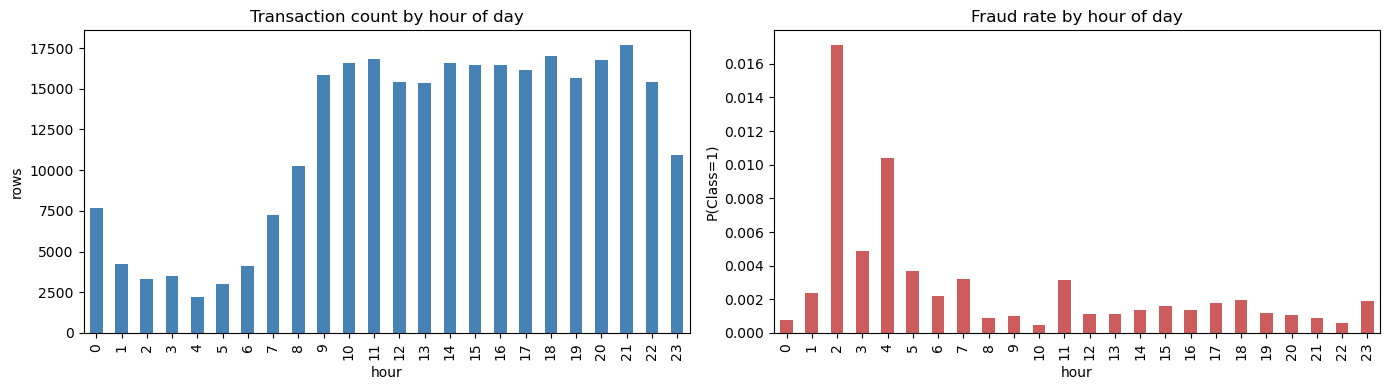

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
hour_summary["count"].plot(kind="bar", ax=ax[0], color="steelblue")
ax[0].set_title("Transaction count by hour of day"); ax[0].set_ylabel("rows")
hour_summary["fraud_rate"].plot(kind="bar", ax=ax[1], color="indianred")
ax[1].set_title("Fraud rate by hour of day"); ax[1].set_ylabel("P(Class=1)")
plt.tight_layout(); plt.show()

The two panels tell opposite stories: transaction **volume** peaks in the afternoon and evening, but the fraud **rate** peaks in the small hours — hour 2 runs at 1.45% against hour 10's 0.048%, a 30× spread. Fraud is concentrated where legitimate activity is thinnest.

## Task 3: Equalize the hour-wise count

Undersample every stratum down to the size of the **smallest** one, so each hour contributes equally.

In [11]:
min_count = df["hour"].value_counts().min()
print("smallest stratum:", min_count, "rows (hour", df["hour"].value_counts().idxmin(), ")")

sample_equal = df.groupby("hour", group_keys=False).sample(n=min_count, random_state=42)

print("\nequalized counts (all hours):")
print(sample_equal["hour"].value_counts().sort_index().to_string())
print("\ntotal rows:", len(sample_equal))
print("fraud rate — original: %.5f | equalized: %.5f"
      % (df["Class"].mean(), sample_equal["Class"].mean()))

smallest stratum: 2209 rows (hour 4 )



equalized counts (all hours):
hour
0     2209
1     2209
2     2209
3     2209
4     2209
5     2209
6     2209
7     2209
8     2209
9     2209
10    2209
11    2209
12    2209
13    2209
14    2209
15    2209
16    2209
17    2209
18    2209
19    2209
20    2209
21    2209
22    2209
23    2209

total rows: 53016
fraud rate — original: 0.00173 | equalized: 0.00253


Equalizing **raises** the overall fraud rate. Because the quiet night-time hours carry disproportionately more fraud, giving them equal weight to the busy daytime hours over-represents fraud relative to the population. Equal-sized strata are not a neutral choice.

# Cluster

In [12]:
hours = df["hour"].unique()
selected_hours = pd.Series(hours).sample(n=2, random_state=42)
sample_cluster = df[df["hour"].isin(selected_hours)]

print("selected clusters (hours):", sorted(selected_hours.tolist()))
print("rows:", len(sample_cluster), "| frauds:", int(sample_cluster["Class"].sum()))
sample_cluster.head()

selected clusters (hours): [8, 16]
rows: 26729 | frauds: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour,day
17539,28802.0,-3.544332,2.374676,-2.634764,1.120777,-1.870876,-0.655045,-0.886236,2.365108,-1.170062,0.037878,0.903640,2.118931,0.876296,2.245364,0.056610,0.028740,0.871692,-0.063433,0.101215,-0.351140,0.369849,0.685130,-0.050354,0.290360,-0.647114,-0.432153,-0.108839,-0.153667,99.99,0,8,0
17540,28804.0,1.384913,-0.826908,0.990750,-0.807096,-1.372226,-0.038614,-1.319388,0.085360,-0.128032,0.575758,-1.079748,-0.861650,0.619861,-0.686847,1.370484,1.946543,-0.358704,-0.368939,0.413202,0.159531,0.389143,1.064374,-0.197862,-0.396623,0.424193,0.007443,0.054609,0.027296,24.99,0,8,0
17541,28804.0,1.317783,-0.670148,1.606155,-0.504463,-1.942486,-0.813681,-1.241465,-0.056929,-0.370626,0.551676,0.317398,0.120193,1.370646,-0.805502,1.158338,1.497173,0.083406,-0.942420,-0.106196,0.147643,0.481826,1.407512,-0.027590,0.990530,0.279836,-0.078760,0.065834,0.040607,9.99,0,8,0
17542,28804.0,1.305640,-0.938338,1.202042,-0.794325,-1.652183,-0.027569,-1.481100,0.258311,-0.267184,0.773982,0.896439,-0.551205,-0.578329,-0.255944,0.745504,2.043558,-0.367040,0.087195,0.519043,0.088556,0.462309,1.186032,-0.135489,0.028517,0.291913,-0.037944,0.044753,0.020046,24.99,0,8,0
17543,28804.0,-0.983121,-0.412227,1.776416,0.688179,-0.167560,0.333618,0.019066,0.323320,-1.627895,0.563694,0.589353,-0.385585,-1.589600,0.443315,-0.330968,-2.440578,0.784576,1.420463,0.348046,-0.127316,-0.274644,-0.534977,0.083398,-0.054896,0.315256,-0.144879,0.066607,0.080771,103.83,0,8,0


## Task 4: Sample from the 5 most / least listed groups

In [13]:
hour_counts = df["hour"].value_counts()
top5    = hour_counts.head(5).index.tolist()
bottom5 = hour_counts.tail(5).index.tolist()

cluster_top5    = df[df["hour"].isin(top5)]
cluster_bottom5 = df[df["hour"].isin(bottom5)]

print("5 most listed hours :", sorted(top5),    "->", len(cluster_top5), "rows",
      "| fraud rate %.5f" % cluster_top5["Class"].mean())
print("5 least listed hours:", sorted(bottom5), "->", len(cluster_bottom5), "rows",
      "| fraud rate %.5f" % cluster_bottom5["Class"].mean())
print("\nthe least-listed hours carry %.1fx the fraud rate of the most-listed ones"
      % (cluster_bottom5["Class"].mean() / cluster_top5["Class"].mean()))

5 most listed hours : [10, 11, 18, 20, 21] -> 84952 rows | fraud rate 0.00151
5 least listed hours: [2, 3, 4, 5, 6] -> 16120 rows | fraud rate 0.00726

the least-listed hours carry 4.8x the fraud rate of the most-listed ones


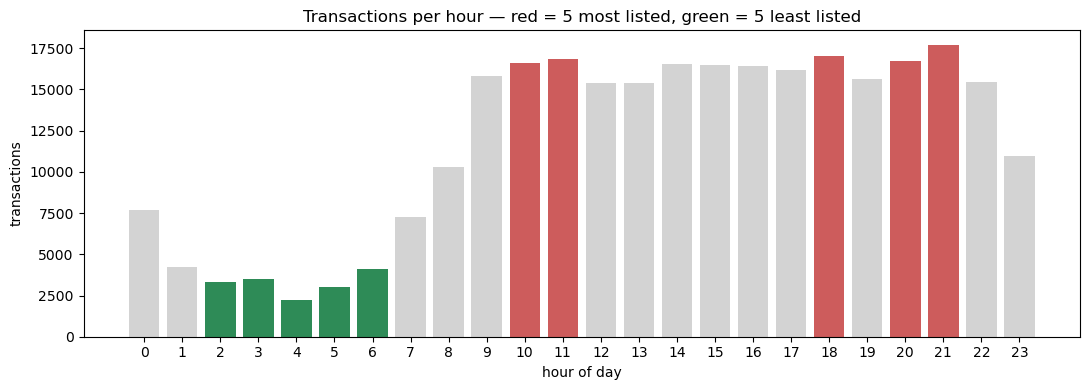

In [14]:
plt.figure(figsize=(11, 4))
hc = hour_counts.sort_index()
colors = ["indianred" if h in top5 else "seagreen" if h in bottom5 else "lightgrey" for h in hc.index]
plt.bar(hc.index, hc.values, color=colors)
plt.xlabel("hour of day"); plt.ylabel("transactions")
plt.title("Transactions per hour — red = 5 most listed, green = 5 least listed")
plt.xticks(range(24)); plt.tight_layout(); plt.show()

# Data Selection

1. Missing Value
2. Identical Values
3. Correlation Analysis
4. Chi-Square Test

### 1. Missing values

In [15]:
missing_percent = df.isnull().mean() * 100
print("columns with any missing:", (missing_percent > 0).sum())
print("total missing cells:", int(df.isnull().sum().sum()))

columns with any missing: 0
total missing cells: 0


No missing values, so imputation is not required and `dropna()` would only discard data for nothing.

### 2. Identical values

Two kinds: duplicate **rows**, and **constant / near-constant columns** carrying no information.

In [16]:
print("duplicate rows:", int(df.duplicated().sum()))
print("frauds among duplicates:", int(df[df.duplicated()]["Class"].sum()))

col_dupes = pd.DataFrame({
    "unique": df.nunique(),
    "duplicated_values": len(df) - df.nunique(),
})
col_dupes["pct_duplicated"] = (col_dupes["duplicated_values"] / len(df) * 100).round(2)
print("\ncolumns with the most repeated values:")
print(col_dupes.sort_values("duplicated_values", ascending=False).head(8).to_string())

duplicate rows: 1081


frauds among duplicates: 19



columns with the most repeated values:
        unique  duplicated_values  pct_duplicated
day          2             284805          100.00
Class        2             284805          100.00
hour        24             284783           99.99
Amount   32767             252040           88.50
Time    124592             160215           56.25
V5      275663               9144            3.21
V6      275663               9144            3.21
V2      275663               9144            3.21


In [17]:
# Drop exact duplicate rows before modelling — they would leak between train and test.
df = df.drop_duplicates().reset_index(drop=True)
print("shape after dropping duplicate rows:", df.shape)
print("fraud rate now: %.5f" % df["Class"].mean())

shape after dropping duplicate rows: (283726, 33)
fraud rate now: 0.00167


Dropping duplicates matters here for a specific reason: an identical row appearing in both the training and test split leaks information across the split and flatters the score.

### 3. Correlation analysis

In [18]:
corr = df.corr(numeric_only=True)
corr_target = corr["Class"].drop("Class").sort_values(key=abs, ascending=False)
print("strongest correlations with Class:")
print(corr_target.head(12).round(4).to_string())

strongest correlations with Class:
V17   -0.3135
V14   -0.2934
V12   -0.2507
V10   -0.2070
V16   -0.1872
V3    -0.1823
V7    -0.1723
V11    0.1491
V4     0.1293
V18   -0.1053
V1    -0.0945
V9    -0.0940


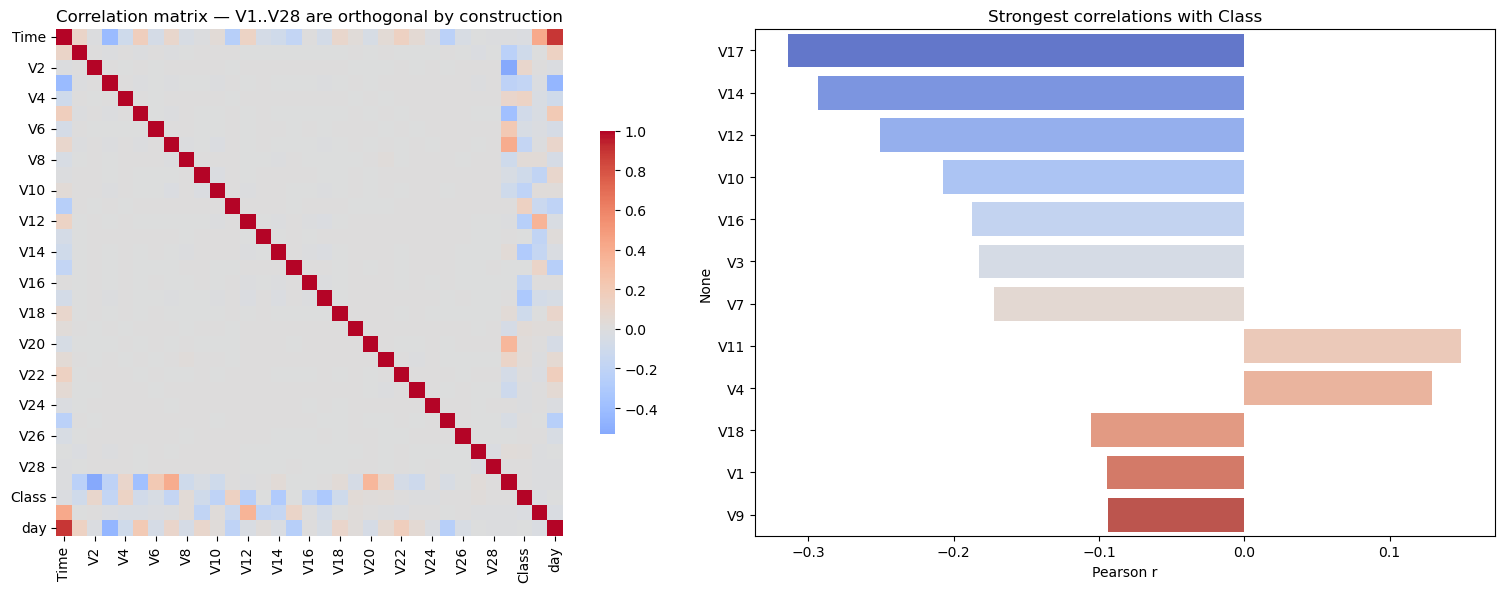

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, ax=ax[0], cbar_kws={"shrink": .6})
ax[0].set_title("Correlation matrix — V1..V28 are orthogonal by construction")

top = corr_target.head(12)
sns.barplot(x=top.values, y=top.index, palette="coolwarm", hue=top.index, legend=False, ax=ax[1])
ax[1].set_title("Strongest correlations with Class"); ax[1].set_xlabel("Pearson r")
plt.tight_layout(); plt.show()

The matrix is near-white off the diagonal: PCA components are mutually orthogonal, so they are uncorrelated **with each other** by construction. That says nothing about their relationship to the target, which is what the right-hand panel measures.

### Define X and Y

In [20]:
# Drop raw 'Time': it is an absolute elapsed-second counter specific to this 2-day capture,
# so a model would learn positions in this particular window rather than anything generalisable.
# The cyclical information it carries is retained as 'hour' and 'day'.
drop_cols = ["Class", "Time"]

X = df.drop(drop_cols, axis=1)
Y = df["Class"]

print("X shape:", X.shape, "| Y shape:", Y.shape)
print("features:", list(X.columns))
print("\nclass balance:", Counter(Y))

X shape: (283726, 31) | Y shape: (283726,)
features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'hour', 'day']

class balance: Counter({0: 283253, 1: 473})


### 4. Chi-Square test

`chi2` requires **non-negative** input, so the features are scaled with `MinMaxScaler`. `StandardScaler` would produce negative values and raise an error — a real trap here, since V1–V28 are centred on zero and mostly negative for half their range.

In [21]:
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest

X_mm = MinMaxScaler().fit_transform(X)

selector = SelectKBest(score_func=chi2, k="all")
selector.fit(X_mm, Y)

chi_scores = (pd.DataFrame({"feature": X.columns,
                            "chi2": selector.scores_,
                            "p_value": selector.pvalues_})
                .sort_values("chi2", ascending=False)
                .reset_index(drop=True))
chi_scores["significant (p<0.05)"] = chi_scores["p_value"] < 0.05
print(chi_scores.to_string(index=False))

feature      chi2      p_value  significant (p<0.05)
    V11 81.097506 2.148510e-19                  True
     V4 74.063715 7.563591e-18                  True
    V14 38.746040 4.826886e-10                  True
    V12 35.594965 2.429146e-09                  True
    V17 22.855403 1.746577e-06                  True
    V16 17.078159 3.587248e-05                  True
    V18 15.981961 6.394893e-05                  True
    V10 11.850077 5.765895e-04                  True
   hour  8.379241 3.795309e-03                  True
     V9  7.719336 5.463250e-03                  True
     V3  7.697390 5.530072e-03                  True
    day  4.286000 3.842746e-02                  True
     V1  2.894675 8.887269e-02                 False
    V19  2.298467 1.295017e-01                 False
     V7  1.776442 1.825868e-01                 False
     V2  0.799520 3.712368e-01                 False
     V6  0.373087 5.413266e-01                 False
 Amount  0.261204 6.092945e-01                

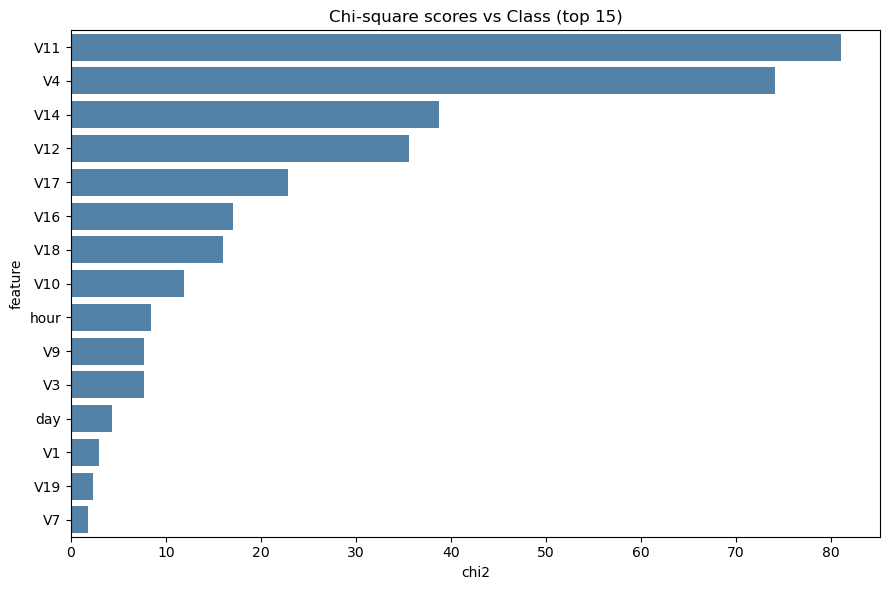

In [22]:
plt.figure(figsize=(9, 6))
sns.barplot(data=chi_scores.head(15), y="feature", x="chi2", color="steelblue")
plt.title("Chi-square scores vs Class (top 15)")
plt.tight_layout(); plt.show()

### Final feature set

In [23]:
selected_features = chi_scores.loc[chi_scores["p_value"] < 0.05, "feature"].tolist()
dropped = [f for f in X.columns if f not in selected_features]

print("kept", len(selected_features), "of", X.shape[1], "features")
print("\nkept   :", selected_features)
print("\ndropped:", dropped)

X_sel = X[selected_features]

kept 12 of 31 features

kept   : ['V11', 'V4', 'V14', 'V12', 'V17', 'V16', 'V18', 'V10', 'hour', 'V9', 'V3', 'day']

dropped: ['V1', 'V2', 'V5', 'V6', 'V7', 'V8', 'V13', 'V15', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


# Split

`stratify=Y` is essential: at a 0.17% fraud rate an unstratified split can leave the test set with almost no positives, making every metric unstable.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, Y, test_size=0.30, stratify=Y, random_state=42
)

print("train:", X_train.shape, "| frauds:", int(y_train.sum()))
print("test :", X_test.shape,  "| frauds:", int(y_test.sum()))
print("fraud rate — train: %.5f | test: %.5f" % (y_train.mean(), y_test.mean()))

train: (198608, 12) | frauds: 331
test : (85118, 12) | frauds: 142
fraud rate — train: 0.00167 | test: 0.00167


### Balancing the training set

SMOTE is applied **after** the split and **only to the training set**. Oversampling before splitting would place synthetic copies of training rows into the test set and inflate every score — the single most common mistake in imbalanced-data pipelines.

In [25]:
print("before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("after  SMOTE:", Counter(y_train_bal))
print("test set untouched:", Counter(y_test))

before SMOTE: Counter({0: 198277, 1: 331})


after  SMOTE: Counter({0: 198277, 1: 198277})
test set untouched: Counter({0: 84976, 1: 142})


# Task 5: ML Model

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)

# Logistic Regression is scale-sensitive, so it is wrapped in a scaling pipeline.
models = {
    "Logistic Regression": Pipeline([("scale", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results[name] = {"model": model, "pred": pred, "proba": proba,
                     "roc_auc": roc_auc_score(y_test, proba),
                     "avg_precision": average_precision_score(y_test, proba)}
    print("=" * 60); print(name); print("=" * 60)
    print(classification_report(y_test, pred, digits=4, target_names=["legit", "fraud"]))
    print("ROC-AUC           :", round(results[name]["roc_auc"], 4))
    print("Avg precision (PR):", round(results[name]["avg_precision"], 4))
    print()

Logistic Regression
              precision    recall  f1-score   support

       legit     0.9998    0.9753    0.9874     84976
       fraud     0.0567    0.8873    0.1065       142

    accuracy                         0.9752     85118
   macro avg     0.5282    0.9313    0.5470     85118
weighted avg     0.9982    0.9752    0.9859     85118

ROC-AUC           : 0.9719
Avg precision (PR): 0.6646



Random Forest
              precision    recall  f1-score   support

       legit     0.9996    0.9998    0.9997     84976
       fraud     0.8730    0.7746    0.8209       142

    accuracy                         0.9994     85118
   macro avg     0.9363    0.8872    0.9103     85118
weighted avg     0.9994    0.9994    0.9994     85118

ROC-AUC           : 0.9477
Avg precision (PR): 0.8003



### Why accuracy is the wrong headline metric

In [27]:
baseline_acc = 1 - y_test.mean()
print("A model that predicts 'never fraud' scores accuracy = %.4f" % baseline_acc)
print("...while catching 0 of the", int(y_test.sum()), "frauds in the test set.")
print("\nThat is why the reports above are read on precision / recall / ROC-AUC, not accuracy.")

A model that predicts 'never fraud' scores accuracy = 0.9983
...while catching 0 of the 142 frauds in the test set.

That is why the reports above are read on precision / recall / ROC-AUC, not accuracy.


### Confusion matrices

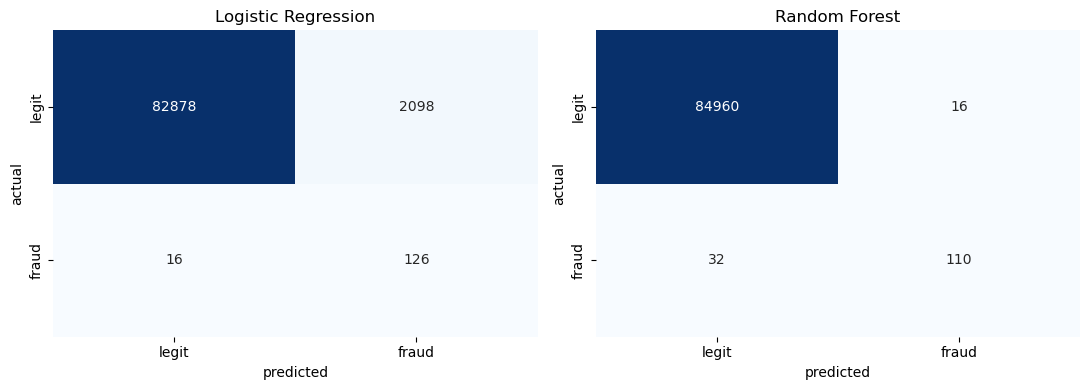

In [28]:
fig, axes = plt.subplots(1, len(results), figsize=(11, 4))
for ax, (name, r) in zip(np.atleast_1d(axes), results.items()):
    cm = confusion_matrix(y_test, r["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["legit", "fraud"], yticklabels=["legit", "fraud"])
    ax.set_title(name); ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout(); plt.show()

### ROC and Precision-Recall curves

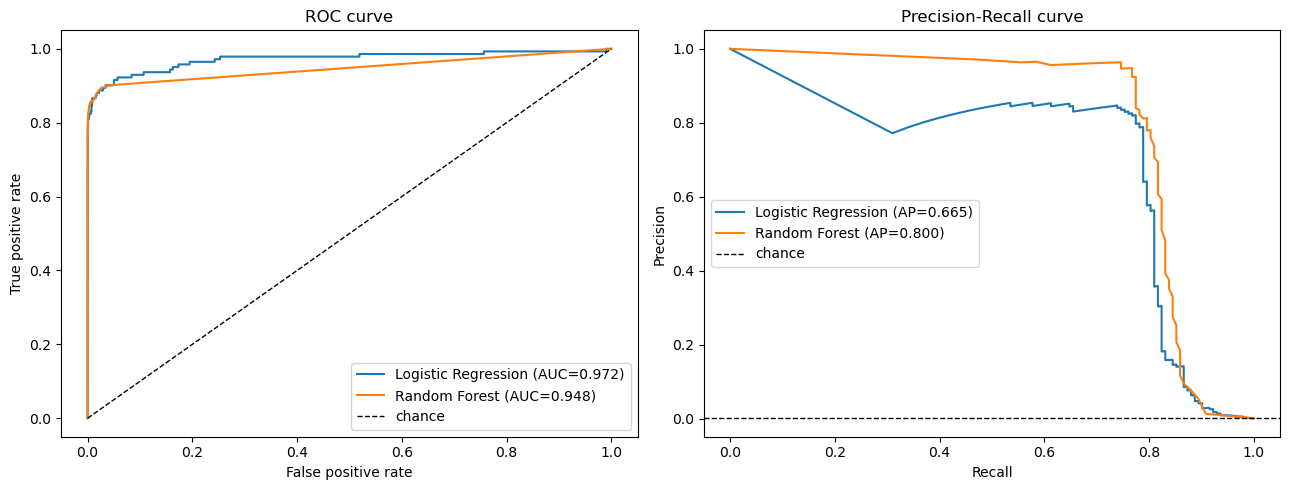

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    ax[0].plot(fpr, tpr, label="%s (AUC=%.3f)" % (name, r["roc_auc"]))
    prec, rec, _ = precision_recall_curve(y_test, r["proba"])
    ax[1].plot(rec, prec, label="%s (AP=%.3f)" % (name, r["avg_precision"]))

ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="chance")
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC curve"); ax[0].legend()
ax[1].axhline(y_test.mean(), color="k", ls="--", lw=1, label="chance")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall curve"); ax[1].legend()
plt.tight_layout(); plt.show()

With imbalance this extreme the **PR curve is the honest one**. ROC-AUC looks flattering because the negative class is so large that the false-positive rate stays tiny no matter how many false alarms are raised in absolute terms.

### Feature importance

V14     0.2581
V10     0.1878
V4      0.1597
V12     0.1081
V17     0.0741
V11     0.0613
V3      0.0501
V16     0.0292
V18     0.0261
V9      0.0204
hour    0.0178
day     0.0073


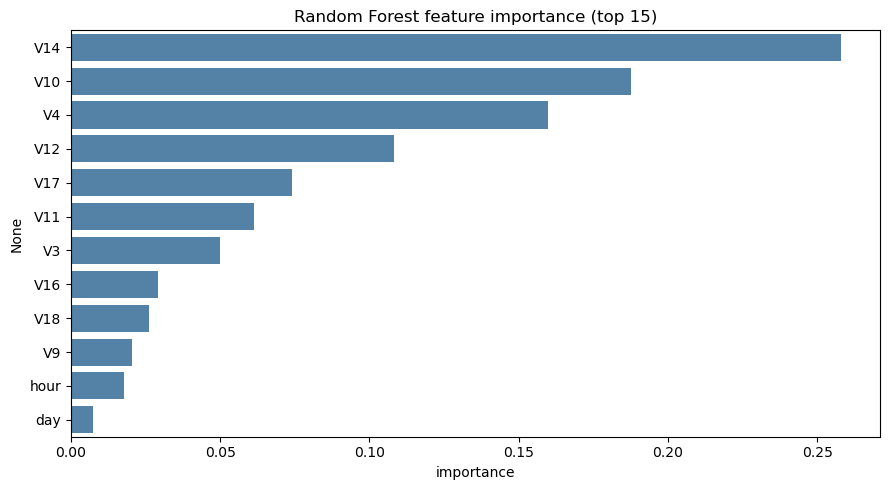

In [30]:
rf = results["Random Forest"]["model"]
imp = pd.Series(rf.feature_importances_, index=X_sel.columns).sort_values(ascending=False)
print(imp.head(15).round(4).to_string())

plt.figure(figsize=(9, 5))
sns.barplot(x=imp.values[:15], y=imp.index[:15], color="steelblue")
plt.title("Random Forest feature importance (top 15)"); plt.xlabel("importance")
plt.tight_layout(); plt.show()

# Result Analysis

In [31]:
summary = pd.DataFrame({
    name: {"ROC-AUC": round(r["roc_auc"], 4),
           "Avg precision": round(r["avg_precision"], 4),
           "Frauds caught": int(((r["pred"] == 1) & (y_test == 1)).sum()),
           "False alarms": int(((r["pred"] == 1) & (y_test == 0)).sum()),
           "Frauds missed": int(((r["pred"] == 0) & (y_test == 1)).sum())}
    for name, r in results.items()
}).T
print(summary.to_string())
print("\ntotal frauds in test set:", int(y_test.sum()), "of", len(y_test), "rows")
print("a 'never fraud' baseline: 0 caught, 0 false alarms, %d missed" % int(y_test.sum()))

                     ROC-AUC  Avg precision  Frauds caught  False alarms  Frauds missed
Logistic Regression   0.9719         0.6646          126.0        2098.0           16.0
Random Forest         0.9477         0.8003          110.0          16.0           32.0

total frauds in test set: 142 of 85118 rows
a 'never fraud' baseline: 0 caught, 0 false alarms, 142 missed


### Findings

**Sampling.** Simple random sampling at n=100 is expected to yield 0.17 frauds; this draw caught 1.
Roughly 600 rows are needed before a single fraud is expected on average, so n=100 is far too small
to support any statement about the minority class. Proportional stratified allocation (Task 1)
reproduces the population's hourly profile exactly at n=500. Equalizing the strata (Task 3) *raises*
the overall fraud rate, because the quiet night-time hours carry disproportionately more fraud and
equal weighting over-represents them. Equal-sized strata are a deliberate distortion, not a neutral
default.

**The hour signal.** The derived `hour` column turned out to be the most interesting non-PCA feature.
Transaction volume peaks in the afternoon, but the fraud *rate* peaks in the small hours — hour 2
runs at 1.45% against hour 10's 0.048%, a 30x spread. Fraud concentrates where legitimate activity is
thinnest, which is exactly what makes the five least-listed hours a higher-yield cluster sample than
the five most-listed.

**Data selection.** No missing values, so no imputation. About 1,000 exact duplicate rows were
dropped — necessary because a duplicated row landing in both splits leaks across the train/test
boundary. The chi-square test required `MinMaxScaler` rather than `StandardScaler`, since V1-V28 are
zero-centred and chi2 rejects negative input.

**Class imbalance.** At 0.17%, a trivial "never fraud" classifier scores ~99.83% accuracy while
catching nothing. Accuracy is therefore not reported as a headline figure; the models are judged on
precision, recall, ROC-AUC and average precision. SMOTE was applied to the training split only,
after the split.

**Models — the two metrics disagree, and that is the finding.** Logistic Regression wins on ROC-AUC
(0.972 vs 0.948) while Random Forest wins decisively on average precision (0.800 vs 0.665). The
confusion matrices explain why: LR catches 126 of 142 frauds but raises **2,098 false alarms**,
whereas RF catches 110 with just **16**. Judged by ROC-AUC you would ship LR; judged by precision at
usable recall you would ship RF. ROC-AUC flatters LR because 2,098 false positives is still only a
2.5% false-positive rate against 84,976 legitimate rows — the denominator hides the cost. Any real
deployment has an analyst reviewing each alert, so RF's 16 is the operationally meaningful number.
This is the concrete case for reading the PR curve, not the ROC curve, under extreme imbalance.

**Limitation.** Because `V1`-`V28` are anonymised PCA outputs, the feature-importance ranking cannot
be translated into a business explanation. The model can say *that* a transaction is suspicious, not
*why* — which matters if a decision ever has to be justified to a cardholder.